# Population Regression from Images (PyTorch)

Train a CNN to predict a population number from each image. The label is parsed
from the filename: the integer between the **last underscore** and `.jpg`
(e.g. `city_region_12345.jpg` -> `12345`).

Run the cells top to bottom. Edit the **Config** cell to change anything.

> **Running on CPU.** The defaults below (small CNN, no pretrained weights,
> balanced + downsampled data, 8 epochs) are tuned to train in minutes on CPU.
> If you later get a GPU working, see the optional note in section 1a.

## 1a. (Optional) GPU later

This notebook runs on CPU as configured. If you ever want to revisit GPU
acceleration on your AMD card, it requires the ROCm build of PyTorch in a
**Python 3.12** environment (the wheels are `cp312`-only; that's what caused the
earlier *circular import* error on Python 3.14). Not needed for now -- the CPU
defaults below are tuned to be fast enough. The device-selection cell still
auto-detects a GPU if one is ever available, so nothing here needs to change.

## 1. Config
Everything tunable lives here.

In [2]:
import os, math, time, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm   # progress bars (pip install tqdm)

# ---------------- EDIT THESE ----------------
DATA_DIR   = r"..\\Data"   # folder of .jpg files
IMAGE_SIZE = 200             # native 200x200 (no resampling). Slower on CPU; drop to 128/96 if needed.
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.10
BATCH_SIZE = 64              # raise if GPU memory allows; lower if you hit OOM
EPOCHS     = 4               # fewer epochs (was 30)
LR         = 5e-4
WEIGHT_DECAY = 1e-4
BACKBONE   = "simple_cnn"    # CPU-friendly small CNN. Use "resnet18" if you get a GPU.
PRETRAINED = False           # pretrained only matters for the resnet backbones
DROPOUT    = 0.2
NUM_WORKERS = 0              # 0 is safest on Windows; try 4 on Linux for speed
EARLY_STOP_PATIENCE = 4
GRAD_CLIP  = 1.0
SEED       = 42

# Balance the data so there are as many zero-population images as non-zero ones
# (applied to train AND test). See section 3.
BALANCE_ZERO_NONZERO = True

# Target normalization. Populations here are a small bounded range (0-200, mostly
# 0), so a log transform is NOT appropriate -- it would distort this range. We
# leave LOG_TARGET off and just standardize (mean 0, std 1, fit on train only),
# which keeps the optimizer well-conditioned. Predictions are inverted back to
# real counts for all reported metrics.
LOG_TARGET = False
STD_TARGET = True

OUT_DIR    = "run_gradcam"   # distinct from the other notebook's "run" folder -- no file collisions
# --------------------------------------------

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

## 1b. Device check

Reports the device in use. CPU is expected here and is fine with the small-CNN
defaults. It will automatically use a GPU if one is ever available.

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")          # ROCm presents AMD GPUs via the CUDA API
    name = torch.cuda.get_device_name(0)
    print(f"device: cuda  ->  {name}")
    print("HIP/ROCm version:", getattr(torch.version, "hip", None))
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("device: mps (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("device: cpu  (expected; small-CNN defaults are tuned for this)")

# cudnn.benchmark only matters on GPU; harmless on CPU
torch.backends.cudnn.benchmark = True
print("CPU threads available:", torch.get_num_threads())

device: cpu  (expected; small-CNN defaults are tuned for this)
CPU threads available: 6


## 2. Read filenames -> population labels

`extract_population` is the **only** part tied to your naming scheme. To change
the label source later, edit just this function -- return an `int`, or `None` to
skip a file.

In [3]:
def extract_population(filename: str):
    """Integer between the last '_' and '.jpg', or None if not parseable."""
    if not filename.lower().endswith(".jpg"):
        return None
    stem = os.path.splitext(filename)[0]
    token = stem.split("_")[-1]
    try:
        return int(token)
    except ValueError:
        return None

paths, pops = [], []
skipped = 0
for name in sorted(os.listdir(DATA_DIR)):
    if not name.lower().endswith(".jpg"):
        continue
    p = extract_population(name)
    if p is None:
        skipped += 1
        continue
    paths.append(os.path.join(DATA_DIR, name))
    pops.append(p)

paths = np.array(paths); pops = np.array(pops)
assert len(paths), f"No usable .jpg files found in {DATA_DIR!r}"
if skipped:
    print(f"skipped {skipped} file(s) with unparseable population")
n_zero = int((pops == 0).sum()); n_nonzero = int((pops != 0).sum())
print(f"found {len(paths)} labeled images  |  zero-pop: {n_zero}   non-zero: {n_nonzero}")

found 9438 labeled images  |  zero-pop: 8002   non-zero: 1436


## 3. Balance, then split

**Balancing (point 2):** we split the data into zero-population and
non-zero-population groups and randomly downsample the larger group so the two
are equal in size. Because we balance *first* and split *each group* with the
same ratios, the resulting train, val, and test sets are each ~50/50 zero vs.
non-zero. (Downsampling means some images of the majority class are not used --
that's the cost of a balanced set.)

In [4]:
rng = np.random.default_rng(SEED)
zero_idx    = np.where(pops == 0)[0]
nonzero_idx = np.where(pops != 0)[0]

if BALANCE_ZERO_NONZERO:
    k = min(len(zero_idx), len(nonzero_idx))
    if k == 0:
        raise ValueError("Cannot balance: one of the groups is empty.")
    zero_sel    = rng.choice(zero_idx,    size=k, replace=False)
    nonzero_sel = rng.choice(nonzero_idx, size=k, replace=False)
    print(f"balancing: using {k} zero + {k} non-zero = {2*k} images "
          f"(dropped {len(paths) - 2*k} from the majority class)")
else:
    zero_sel, nonzero_sel = zero_idx, nonzero_idx

def split_group(indices):
    """Shuffle one group and cut it into train/val/test by the global ratios."""
    indices = rng.permutation(indices)
    n = len(indices)
    n_test = int(round(n * TEST_SPLIT))
    n_val  = int(round(n * VAL_SPLIT))
    return (indices[n_test + n_val:],        # train
            indices[n_test:n_test + n_val],  # val
            indices[:n_test])                # test

# Split each class separately, then concatenate -> every split stays ~balanced
ztr, zva, zte = split_group(zero_sel)
ntr, nva, nte = split_group(nonzero_sel)
train_idx = rng.permutation(np.concatenate([ztr, ntr]))
val_idx   = rng.permutation(np.concatenate([zva, nva]))
test_idx  = rng.permutation(np.concatenate([zte, nte]))

def take(ix):
    return list(paths[ix]), [int(v) for v in pops[ix]]

train_paths, train_pops = take(train_idx)
val_paths,   val_pops   = take(val_idx)
test_paths,  test_pops  = take(test_idx)

def frac_zero(p):
    return (np.array(p) == 0).mean() if len(p) else float("nan")
print(f"train={len(train_paths)} ({frac_zero(train_pops):.0%} zero)  "
      f"val={len(val_paths)} ({frac_zero(val_pops):.0%} zero)  "
      f"test={len(test_paths)} ({frac_zero(test_pops):.0%} zero)")

balancing: using 1436 zero + 1436 non-zero = 2872 images (dropped 6566 from the majority class)
train=2154 (50% zero)  val=430 (50% zero)  test=288 (50% zero)


## 4. Target normalization (fit on train only)

In [5]:
_t = np.asarray(train_pops, dtype=np.float64)
if LOG_TARGET:
    _t = np.log1p(_t)
TARGET_MEAN = float(_t.mean()) if STD_TARGET else 0.0
TARGET_STD  = (float(_t.std()) or 1.0) if STD_TARGET else 1.0

def encode_target(value: float) -> float:
    x = math.log1p(value) if LOG_TARGET else float(value)
    if STD_TARGET:
        x = (x - TARGET_MEAN) / TARGET_STD
    return x

def decode_target(x):
    x = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x, dtype=np.float64)
    if STD_TARGET:
        x = x * TARGET_STD + TARGET_MEAN
    if LOG_TARGET:
        x = np.expm1(x)
    return x

print(f"target mean={TARGET_MEAN:.4f}  std={TARGET_STD:.4f}")

target mean=7.9717  std=17.9201


## 5. Dataset & DataLoaders
Augmentation on the train split only.

In [8]:
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PopulationDataset(Dataset):
    def __init__(self, paths, pops, tf):
        self.paths, self.pops, self.tf = paths, pops, tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        try:
            with Image.open(self.paths[i]) as img:
                image = self.tf(img.convert("RGB"))
        except (OSError, ValueError) as e:
            print(f"warn: failed to load {self.paths[i]}: {e}; using blank")
            image = self.tf(Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE)))
        target = torch.tensor(encode_target(self.pops[i]), dtype=torch.float32)
        return image, target

train_ds = PopulationDataset(train_paths, train_pops, train_tf)
val_ds   = PopulationDataset(val_paths,   val_pops,   eval_tf)
test_ds  = PopulationDataset(test_paths,  test_pops,  eval_tf)

_loader = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
               pin_memory=(device.type == "cuda"))
train_ld = DataLoader(train_ds, shuffle=True, drop_last=True, **_loader)
val_ld   = DataLoader(val_ds,   shuffle=False, **_loader)
test_ld  = DataLoader(test_ds,  shuffle=False, **_loader)
print(f"batches/epoch: train={len(train_ld)}  val={len(val_ld)}  test={len(test_ld)}")

batches/epoch: train=33  val=7  test=5


## 6. Model (two heads: presence + count)

The network shares a feature trunk, then splits into two heads:

* **presence** -- a single logit for "does anyone live here?" (0 vs. >0),
  trained with binary cross-entropy. This is the head we weight heavily.
* **count** -- a single regression value for the (standardized) population,
  trained with SmoothL1 only on images that actually have people.

At prediction time we gate the count by presence: if presence says "empty",
the predicted count is 0; otherwise we use the regression head.

In [9]:
class TwoHeadNet(nn.Module):
    """Shared trunk -> (presence_logit, count). Works for simple_cnn or resnet."""
    def __init__(self, trunk, feat_dim, dropout=0.2):
        super().__init__()
        self.trunk = trunk            # outputs a (N, feat_dim) feature vector
        self.presence = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, 1))
        self.count    = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, 1))
    def forward(self, x):
        f = self.trunk(x)
        return self.presence(f).squeeze(1), self.count(f).squeeze(1)

class SimpleCNNTrunk(nn.Module):
    """Small CNN that outputs a 256-dim feature vector (no final head)."""
    def __init__(self):
        super().__init__()
        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3,32), block(32,64), block(64,128), block(128,256))
        self.pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Linear(256,128), nn.ReLU(inplace=True))
        self.out_dim = 128
    def forward(self, x):
        return self.pool(self.features(x))

def build_model():
    if BACKBONE == "simple_cnn":
        trunk = SimpleCNNTrunk()
        return TwoHeadNet(trunk, trunk.out_dim, DROPOUT)
    ctor, weights = {
        "resnet18": (models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1),
        "resnet34": (models.resnet34, models.ResNet34_Weights.IMAGENET1K_V1),
        "resnet50": (models.resnet50, models.ResNet50_Weights.IMAGENET1K_V2),
    }[BACKBONE]
    net = ctor(weights=weights if PRETRAINED else None)
    feat_dim = net.fc.in_features
    net.fc = nn.Identity()            # expose features; TwoHeadNet adds the heads
    return TwoHeadNet(net, feat_dim, DROPOUT)

model = build_model().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{BACKBONE} (two-head): {n_params:,} trainable params")

simple_cnn (two-head): 1,207,330 trainable params


## 7. Loss, optimizer, scheduler, metrics

**This is where the 0-vs-nonzero priority lives.** The total loss is

```
loss = PRESENCE_WEIGHT * BCE(presence) + count_loss(only where pop > 0)
```

* `BCE(presence)` penalizes getting the "anyone home?" decision wrong -- this is
  the 0/1 error you want to punish hardest. Raise `PRESENCE_WEIGHT` to focus the
  model more on presence; lower it to care more about the actual counts.
* `count_loss` (SmoothL1) is applied **only to images that truly have people**,
  so the model isn't pulled around trying to regress a magnitude for empty
  images -- the presence head handles those. This is exactly why 1-2 / 3-4 /
  5-10 magnitude errors matter less than the 0/1 boundary.

In [10]:
# ---- the knob that controls the priority ----
PRESENCE_WEIGHT = 5.0   # >1 emphasizes the 0-vs-nonzero decision; try 2-10

bce_fn   = nn.BCEWithLogitsLoss()   # presence head (operates on the logit)
count_fn = nn.SmoothL1Loss()        # count head, masked to nonzero images

def compute_loss(presence_logit, count_pred, targets):
    """targets are ENCODED population values; decode to know true zero/nonzero."""
    real = decode_target(targets)                     # back to 0..200 counts
    is_present = torch.tensor(real > 0.5, dtype=torch.float32, device=targets.device)
    presence_loss = bce_fn(presence_logit, is_present)
    # count loss only on images that actually have people
    mask = is_present > 0.5
    if mask.any():
        count_loss = count_fn(count_pred[mask], targets[mask])
    else:
        count_loss = torch.zeros((), device=targets.device)
    return PRESENCE_WEIGHT * presence_loss + count_loss, presence_loss, count_loss

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    ss_res = float(np.sum(err**2))
    ss_tot = float(np.sum((y_true - y_true.mean())**2)) or 1.0
    r2 = 1.0 - ss_res/ss_tot
    # presence-focused metrics: how well do we call 0 vs >0?
    true_present = y_true > 0.5
    pred_present = y_pred > 0.5
    presence_acc = float((true_present == pred_present).mean())
    # of the truly-empty, how many did we correctly call empty (and vice versa)
    tp = int((pred_present & true_present).sum()); fp = int((pred_present & ~true_present).sum())
    fn = int((~pred_present & true_present).sum())
    prec = tp / (tp + fp) if (tp+fp) else float("nan")
    rec  = tp / (tp + fn) if (tp+fn) else float("nan")
    # MAE computed only where someone actually lives (the count quality)
    nz = true_present
    mae_nonzero = float(np.mean(np.abs(err[nz]))) if nz.any() else float("nan")
    return {"mae": mae, "rmse": rmse, "r2": r2, "presence_acc": presence_acc,
            "precision": prec, "recall": rec, "mae_nonzero": mae_nonzero}

## 8. Train & evaluate loops

The training loop uses a **`tqdm` progress bar per epoch** showing batch progress
within the epoch, live loss, and iterations/sec (point 4). An outer bar tracks
overall epoch progress.

In [11]:
def run_epoch(loader, train: bool, epoch: int, n_epochs: int):
    model.train() if train else model.eval()
    total_loss, enc_true, final_pred = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    desc = f"Epoch {epoch}/{n_epochs} " + ("train" if train else "val  ")
    bar = tqdm(loader, desc=desc, leave=False, unit="batch")
    with ctx:
        for step, (images, targets) in enumerate(bar, 1):
            images  = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            presence_logit, count_pred = model(images)
            loss, p_loss, c_loss = compute_loss(presence_logit, count_pred, targets)
            if train:
                optimizer.zero_grad(); loss.backward()
                if GRAD_CLIP > 0:
                    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item()
            # gated final prediction: if presence says empty -> 0, else decoded count
            present = (torch.sigmoid(presence_logit) > 0.5)
            counts = torch.from_numpy(decode_target(count_pred)).to(present.device)
            gated = torch.where(present, counts, torch.zeros_like(counts))
            gated = torch.clamp(gated, min=0.0)        # counts can't be negative
            enc_true.append(targets.detach().cpu().numpy())
            final_pred.append(gated.detach().cpu().numpy())
            bar.set_postfix(loss=f"{total_loss/step:.4f}",
                            p=f"{p_loss.item():.3f}", c=f"{c_loss.item():.3f}")
    bar.close()
    y_true = decode_target(np.concatenate(enc_true))
    y_pred = np.concatenate(final_pred)
    metrics = regression_metrics(y_true, y_pred)
    return total_loss / max(len(loader), 1), metrics

## 9. Train

In [11]:
best_val = float("inf"); patience = 0
ckpt_path = os.path.join(OUT_DIR, "best_model.pt")

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="Total", unit="epoch")
for epoch in epoch_bar:
    train_loss, _    = run_epoch(train_ld, True,  epoch, EPOCHS)
    val_loss, val_m  = run_epoch(val_ld,   False, epoch, EPOCHS)
    scheduler.step()
    epoch_bar.set_postfix(train=f"{train_loss:.3f}", val=f"{val_loss:.3f}",
                          presAcc=f"{val_m['presence_acc']:.2f}",
                          maeNZ=f"{val_m['mae_nonzero']:.1f}")
    tqdm.write(f"epoch {epoch:2d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  "
               f"presence_acc={val_m['presence_acc']:.3f}  "
               f"precision={val_m['precision']:.3f}  recall={val_m['recall']:.3f}  "
               f"MAE_nonzero={val_m['mae_nonzero']:.1f}")
    if val_loss < best_val:
        best_val = val_loss; patience = 0
        torch.save({"model_state": model.state_dict(),
                    "target": {"mean": TARGET_MEAN, "std": TARGET_STD,
                               "log": LOG_TARGET, "std_on": STD_TARGET},
                    "backbone": BACKBONE, "epoch": epoch}, ckpt_path)
        tqdm.write(f"  -> new best, saved {ckpt_path}")
    else:
        patience += 1
        if patience >= EARLY_STOP_PATIENCE:
            tqdm.write(f"early stop after {patience} epochs without improvement")
            break
epoch_bar.close()

Total:   0%|          | 0/4 [00:00<?, ?epoch/s]

Epoch 1/4 train:   0%|          | 0/33 [00:00<?, ?batch/s]

Epoch 1/4 val  :   0%|          | 0/7 [00:00<?, ?batch/s]

epoch  1/4  train=2.4123  val=1.6340  presence_acc=0.900  precision=0.852  recall=0.967  MAE_nonzero=8.8
  -> new best, saved run_gradcam\best_model.pt


Epoch 2/4 train:   0%|          | 0/33 [00:00<?, ?batch/s]

...

Epoch 3/4 val  :   0%|          | 0/7 [00:00<?, ?batch/s]

epoch  3/4  train=1.7746  val=2.1950  presence_acc=0.856  precision=0.780  recall=0.991  MAE_nonzero=11.1


Epoch 4/4 train:   0%|          | 0/33 [00:00<?, ?batch/s]

Epoch 4/4 val  :   0%|          | 0/7 [00:00<?, ?batch/s]

epoch  4/4  train=1.5863  val=1.3407  presence_acc=0.905  precision=0.866  recall=0.958  MAE_nonzero=8.2
  -> new best, saved run_gradcam\best_model.pt


## 10. Final test evaluation (best checkpoint)

In [12]:
ckpt_path = os.path.join(OUT_DIR, "best_model.pt")
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
test_loss, test_m = run_epoch(test_ld, False, ckpt["epoch"], EPOCHS)
print(f"TEST  loss={test_loss:.4f}")
print(f"  presence (0 vs >0):  accuracy={test_m['presence_acc']:.3f}  "
      f"precision={test_m['precision']:.3f}  recall={test_m['recall']:.3f}")
print(f"  count quality:       MAE_nonzero={test_m['mae_nonzero']:.2f}  "
      f"overall MAE={test_m['mae']:.2f}  RMSE={test_m['rmse']:.2f}  R2={test_m['r2']:.3f}")

Epoch 4/4 val  :   0%|          | 0/5 [00:00<?, ?batch/s]

TEST  loss=1.7389
  presence (0 vs >0):  accuracy=0.885  precision=0.845  recall=0.944
  count quality:       MAE_nonzero=8.14  overall MAE=4.82  RMSE=12.66  R2=0.396


## 11. Predict on new images

In [13]:
def predict(image_paths, return_presence=False):
    """Predict population per image. Presence head gates the count:
    if the model says 'empty', the prediction is 0; otherwise the count head."""
    if isinstance(image_paths, str):
        if os.path.isdir(image_paths):
            image_paths = [os.path.join(image_paths, f) for f in sorted(os.listdir(image_paths))
                           if f.lower().endswith(".jpg")]
        else:
            image_paths = [image_paths]
    model.eval()
    out = []
    with torch.no_grad():
        for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="predict", unit="batch"):
            chunk = image_paths[i:i+BATCH_SIZE]
            batch, names = [], []
            for f in chunk:
                try:
                    with Image.open(f) as img:
                        batch.append(eval_tf(img.convert("RGB"))); names.append(f)
                except Exception as e:
                    print(f"skip {f}: {e}")
            if not batch:
                continue
            presence_logit, count_pred = model(torch.stack(batch).to(device))
            prob = torch.sigmoid(presence_logit).cpu().numpy()
            counts = np.clip(decode_target(count_pred), 0, None)
            gated = np.where(prob > 0.5, counts, 0.0)
            for n, g, p in zip(names, np.atleast_1d(gated), np.atleast_1d(prob)):
                out.append((os.path.basename(n), float(g), float(p)) if return_presence
                           else (os.path.basename(n), float(g)))
    return out

## 12. Grad-CAM -- "open the box" on a single image

This does **not** change the model or training -- it's a diagnostic lens. For one
image it shows where the network looked when making a decision, as a heatmap
overlaid on the picture. Hot (red) = this region drove the prediction.

Because you have two heads, you can probe either:
* `head="presence"` -> where it looked to decide *anyone lives here*
* `head="count"`    -> where it looked to decide *how many*

Use it to understand failures: if a wrong prediction's heatmap sits on a field or
on image brightness rather than on structures, you've found the model's shortcut.
Note: the map reflects what drove the model's *decision*, which matches houses
only if the model actually learned to use them -- that's exactly what you're checking.

**On resolution:** the heatmap is rendered at the full input size (200x200) so it
overlays your image exactly, but Grad-CAM is computed on the last conv layer's
grid (~12x12 here) and upsampled. So you get clean alignment, not fine detail --
read it as "which region," not "which pixel." That coarseness is inherent to the
method, and it's enough for the structures-vs-field question you care about.

C:\Users\jacob\AppData\Local\Temp\ipykernel_2508\3148459478.py:32: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


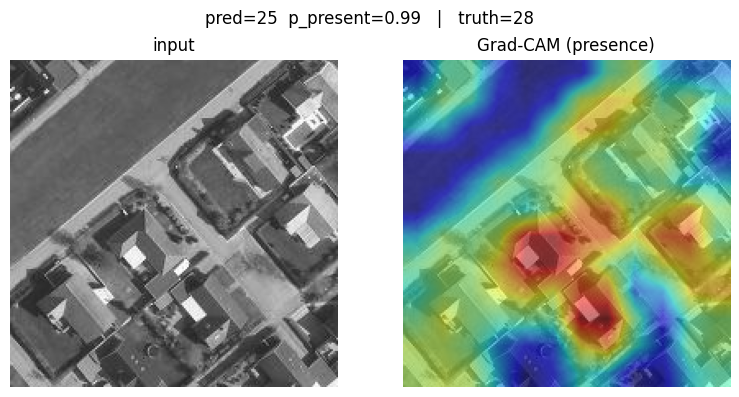

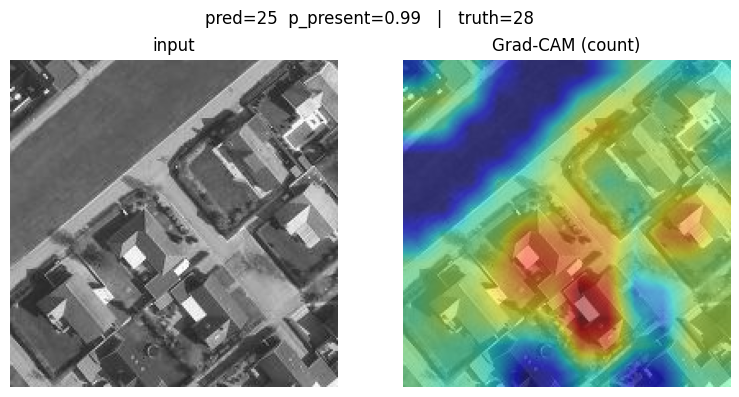

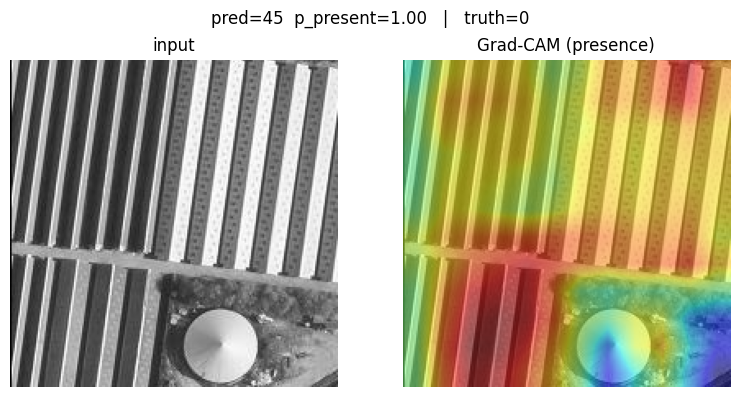

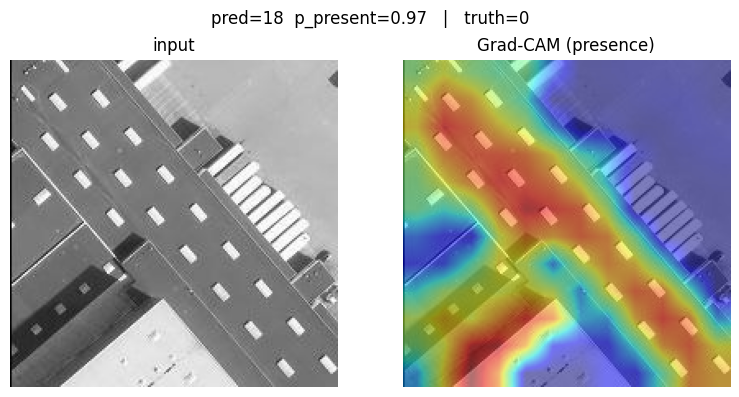

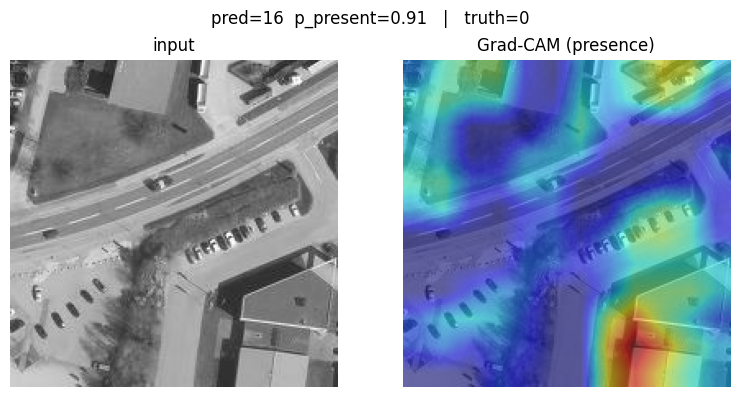

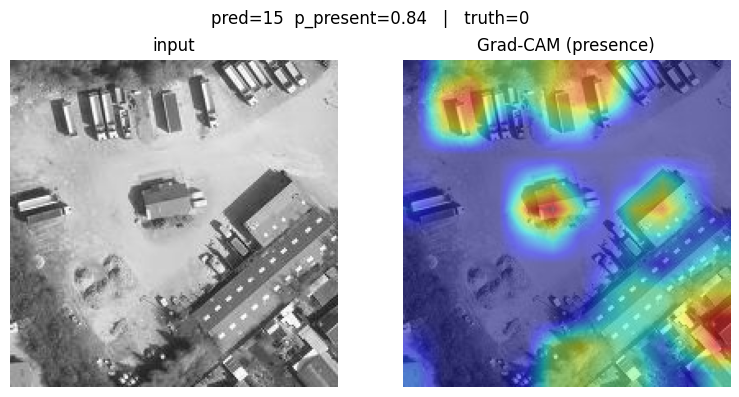

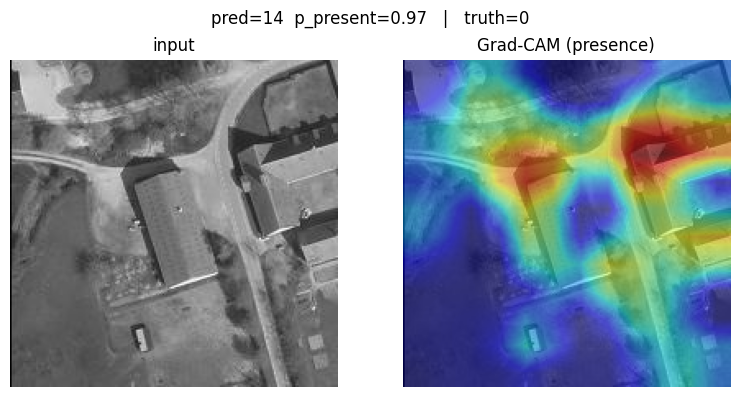

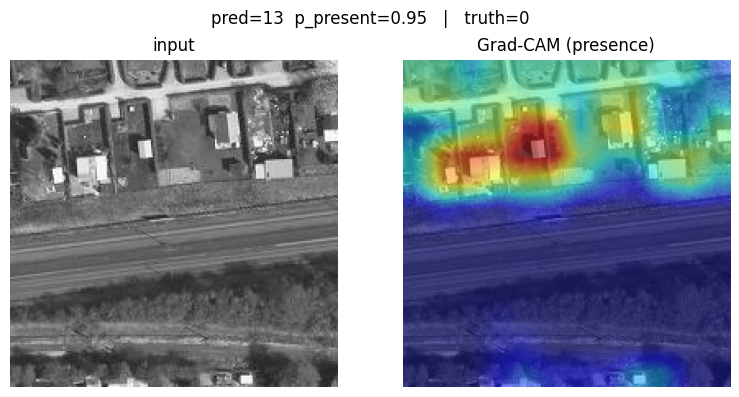

In [17]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def _last_conv_layer():
    """Pick the last convolutional feature stage for the active backbone."""
    if BACKBONE == "simple_cnn":
        return model.trunk.features      # output before global pooling
    else:
        return model.trunk.layer4        # resnet's final conv stage

def grad_cam(image_path, head="presence", show=True):
    """Compute and (optionally) plot a Grad-CAM heatmap for one image.
    head: 'presence' or 'count'. Returns (predicted_pop, p_present, heatmap)."""
    model.eval()
    target_layer = _last_conv_layer()

    activations, gradients = {}, {}
    def fwd_hook(m, inp, out): activations["v"] = out.detach()
    def bwd_hook(m, gin, gout): gradients["v"] = gout[0].detach()
    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # load + preprocess (same transform as eval)
    with Image.open(image_path) as im:
        pil = im.convert("RGB")
    x = eval_tf(pil).unsqueeze(0).to(device)

    # forward (with grad) and pick the scalar to explain
    presence_logit, count_pred = model(x)
    score = presence_logit[0] if head == "presence" else count_pred[0]
    model.zero_grad()
    score.backward()

    # Grad-CAM: GAP the gradients to get per-channel weights, weight the activations
    acts = activations["v"][0]                 # (C, h, w)
    grads = gradients["v"][0]                   # (C, h, w)
    weights = grads.mean(dim=(1, 2))            # (C,)
    cam = F.relu((weights[:, None, None] * acts).sum(0))   # (h, w)
    cam_max = cam.max()
    degenerate = bool(cam_max < 1e-8)   # all-zero map: nothing pushed this output up
    cam = cam / (cam_max + 1e-8)
    # Upsample the coarse conv-grid map (~12x12 for simple_cnn, ~7x7 for resnet)
    # to the full input size so it overlays the image pixel-for-pixel. This makes
    # the map ALIGN with the 200x200 input but does NOT add detail: the real
    # granularity is the conv-grid size, just smoothly stretched.
    cam = F.interpolate(cam[None, None], size=(IMAGE_SIZE, IMAGE_SIZE),
                        mode="bilinear", align_corners=False)[0, 0].cpu().numpy()

    h1.remove(); h2.remove()

    # decode predictions for the caption
    prob = torch.sigmoid(presence_logit)[0].item()
    pop = float(np.clip(decode_target(count_pred), 0, None)[0])
    gated = pop if prob > 0.5 else 0.0

    if show:
        disp = pil.resize((IMAGE_SIZE, IMAGE_SIZE))
        truth = extract_population(os.path.basename(image_path))
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(disp); ax[0].set_title("input"); ax[0].axis("off")
        ax[1].imshow(disp); ax[1].imshow(cam, cmap="jet", alpha=0.5)
        ax[1].set_title(f"Grad-CAM ({head})"); ax[1].axis("off")
        cap = f"pred={gated:.0f}  p_present={prob:.2f}"
        if truth is not None:
            cap += f"   |   truth={truth}"
        if degenerate:
            cap += "   [flat map: no positive evidence for this head]"
        fig.suptitle(cap); plt.tight_layout(); plt.show()
    return gated, prob, cam

# --- Examples ---
i = 10
# Look at one image through the presence head:
grad_cam(test_paths[i], head="presence")
# Same image, count head:
grad_cam(test_paths[i], head="count")

# Sweep the worst presence mistakes to see WHY they failed:
def show_failures(n=6, head="presence"):
    rows = []
    for p, truth in zip(test_paths, test_pops):
        pred, prob, _ = grad_cam(p, head=head, show=False)
        wrong_presence = (prob > 0.5) != (truth > 0)
        rows.append((wrong_presence, abs(pred - truth), p, truth))
    rows.sort(key=lambda r: (not r[0], -r[1]))   # presence errors first, then big count errors
    for _, _, p, truth in rows[:n]:
        grad_cam(p, head=head)
show_failures(6)

C:\Users\jacob\AppData\Local\Temp\ipykernel_2508\3148459478.py:32: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


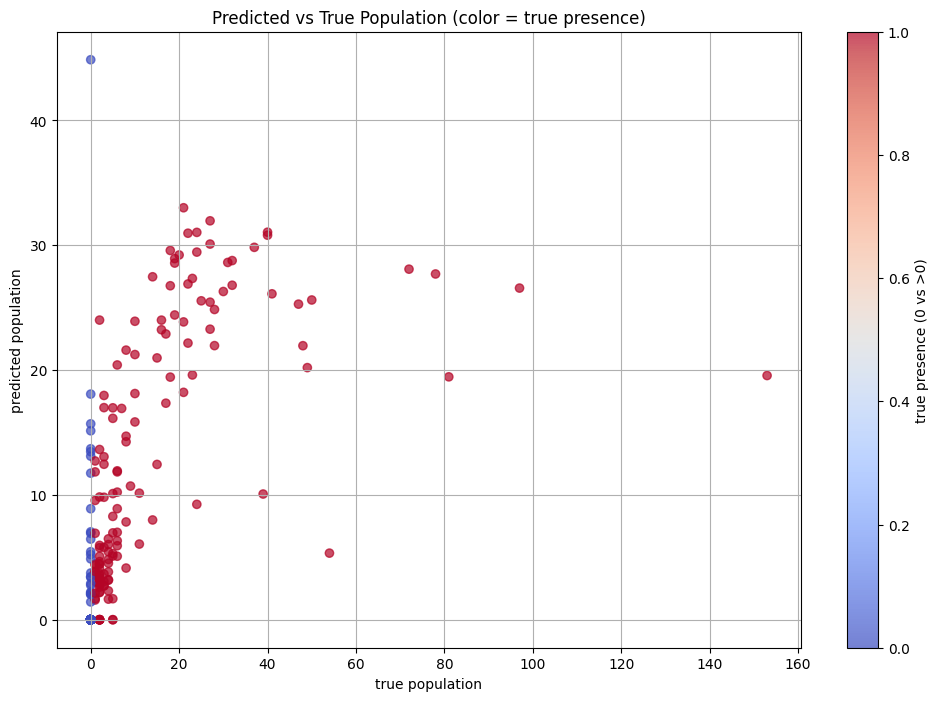

In [ ]:
#Plotting true vs predicted counts, colored by presence/absence:
pred_pops = []
pred_probs = []
for p in test_paths:
    pred, prob, _ = grad_cam(p, head="presence", show=False)
    pred_pops.append(pred)
    pred_probs.append(prob)
true_pops = test_pops
true_probs = [0.0 if t == 0 else 1.0 for t in test_pops]






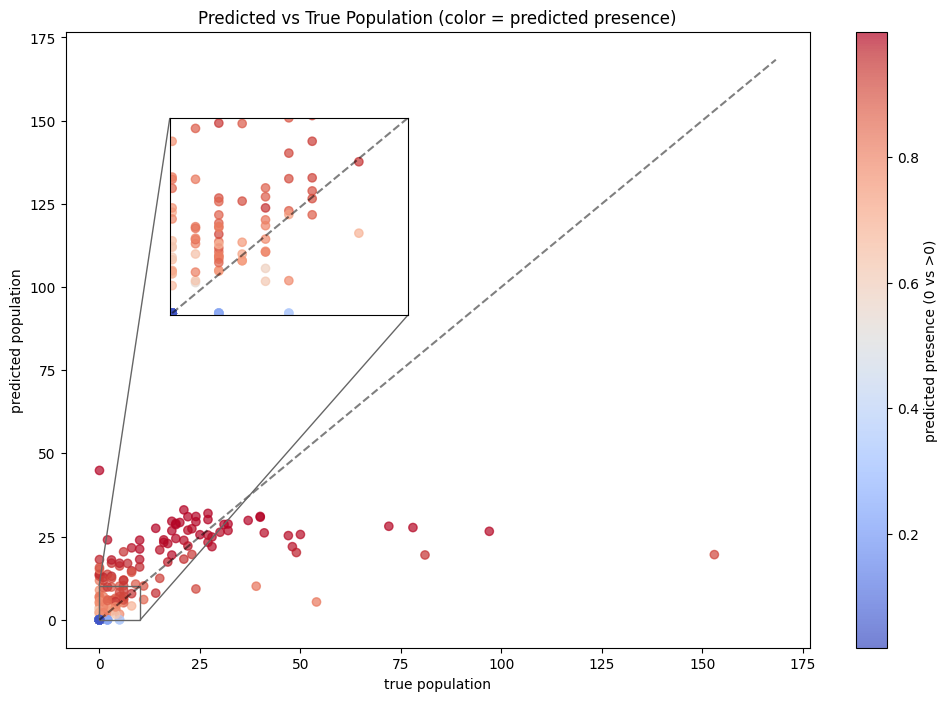

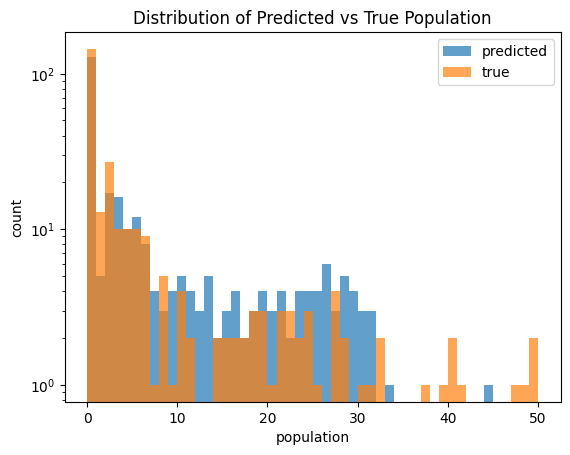

In [49]:
# Add zoomed in view of the low-population region as a subplot in the upper left corner
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(true_pops, pred_pops, c=pred_probs, cmap="coolwarm", alpha=0.7)
plt.colorbar(ax.collections[0], ax=ax, label="predicted presence (0 vs >0)")
ax.set_xlabel("true population")
ax.set_ylabel("predicted population")
ax.set_title("Predicted vs True Population (color = predicted presence)")
ax.grid(False)
max_pop = max(max(true_pops), max(pred_pops)) * 1.1
ax.plot([0, max_pop], [0, max_pop], "k--", alpha=0.5)

# Add zoomed inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Create inset: centered vertically, offset ~0.3 of width toward the left
# Using bbox_to_anchor in axes-fraction coordinates
axins = inset_axes(
    ax,
    width="40%",      # inset width as % of parent axes
    height="40%",     # inset height as % of parent axes
    bbox_to_anchor=(-0.1, 0.3, 0.8, 0.8),  # (x0, y0, w, h) in axes fraction
    bbox_transform=ax.transAxes,
    loc="center",
    borderpad=0,
)

# Replot the same data on the inset
axins.scatter(true_pops, pred_pops, c=pred_probs, cmap="coolwarm", alpha=0.7)
axins.plot([0, max_pop], [0, max_pop], "k--", alpha=0.5)

# Zoom region
x1, x2, y1, y2 = 0, 10, 0, 10
axins.set_xlim(x1-0.1, x2+0.1)  # add small margin for visibility
axins.set_ylim(y1-0.1, y2+0.1)
axins.set_xticks([])      # optional: clean look like the reference
axins.set_yticks([])
axins.grid(True)

# Draw the "zoom lines" connecting the inset to the source region
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=1)

plt.show()

bins = np.arange(0,51,1)
plt.hist(pred_pops, bins=bins, alpha=0.7, label="predicted")
plt.hist(true_pops, bins=bins, alpha=0.7, label="true")
plt.xlabel("population")
plt.ylabel("count")
plt.title("Distribution of Predicted vs True Population")
#Getting log y-scale
plt.yscale("log")
plt.legend()